# Multi-Armed Bandit Recommender

## Data preparation

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os, zipfile, subprocess
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Download dataset if needed
zip_path = "amazon-product-reviews.zip"
if not os.path.exists(zip_path):
    print("Downloading dataset...")
    subprocess.run(["kaggle", "datasets", "download", "-d", "arhamrumi/amazon-product-reviews"], check=True)
    print("Download complete.")

# Extract if needed
csv_path = "Reviews.csv"
if not os.path.exists(csv_path):
    print("Extracting zip...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(".")
    print("Extraction complete.")

# Load and clean
print("Loading Reviews.csv...")
df = pd.read_csv("Reviews.csv")
print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

df["ProfileName"] = df["ProfileName"].fillna("Unknown")
df["Summary"]     = df["Summary"].fillna("")
df["full_text"]   = (df["Summary"] + " " + df["Text"]).str.strip()
df["review_time"] = pd.to_datetime(df["Time"], unit="s")
df["helpfulness_ratio"] = np.where(
    df["HelpfulnessDenominator"] > 0,
    df["HelpfulnessNumerator"] / df["HelpfulnessDenominator"], 0
)
df["text_length_chars"] = df["Text"].astype(str).apply(len)
df["text_length_words"] = df["Text"].astype(str).apply(lambda x: len(x.split()))
print("Cleaning done.")

# Filter to active users and products
print("Filtering to active users and products...")
min_user_reviews    = 5
min_product_reviews = 5
user_counts    = df["UserId"].value_counts()
product_counts = df["ProductId"].value_counts()
df_model = df[
    df["UserId"].isin(user_counts[user_counts >= min_user_reviews].index) &
    df["ProductId"].isin(product_counts[product_counts >= min_product_reviews].index)
].copy()
print(f"Filtered: {df_model.shape[0]:,} rows | {df_model['UserId'].nunique():,} users | {df_model['ProductId'].nunique():,} products")

# Define relevance (reward signal)
relevance_threshold = 4
df_model["is_relevant"] = (df_model["Score"] >= relevance_threshold).astype(int)
print(f"Relevant interaction rate: {df_model['is_relevant'].mean():.4f}")

# Train/test split
train_df, test_df = train_test_split(df_model, test_size=0.2, random_state=42)
print(f"Train: {train_df.shape[0]:,} rows | Test: {test_df.shape[0]:,} rows")
print("Data preparation complete.")

Filtered: (219540, 15) | users: 23262 | products: 17538
Relevant interaction rate: 0.7823
Train: (175632, 16) | Test: (43908, 16)


## MAB Framework

In a Multi-Armed Bandit recommender, each product is an arm with a Beta(α, β) distribution representing our belief about its "like probability." The system selects an arm via a policy, observes the user's reaction (reward), and updates that arm's distribution accordingly.

Values of α are counts of positive rewards, while values of β are counts of negative rewards.

An important concept in MAB is exploration vs. exploitation: recommending what we *think* is best (exploit) vs. trying uncertain options to learn more (explore). Each policy balances this differently.

In [2]:
class MABRecommender:
    def __init__(self, product_ids):
        self.arms = {pid: [1, 1] for pid in product_ids}  # Beta(α=1, β=1) prior
        self.total_pulls = 0

    def select_arm(self):
        raise NotImplementedError

    def update(self, product_id, reward):
        if reward == 1:
            self.arms[product_id][0] += 1
        else:
            self.arms[product_id][1] += 1
        self.total_pulls += 1

    def expected_reward(self, product_id):
        a, b = self.arms[product_id]
        return a / (a + b)


class EpsilonGreedy(MABRecommender):
    def __init__(self, product_ids, epsilon=0.1):
        super().__init__(product_ids)
        self.epsilon = epsilon

    def select_arm(self):
        if np.random.random() < self.epsilon:
            return np.random.choice(list(self.arms.keys()))
        return max(self.arms, key=lambda pid: self.expected_reward(pid))


class UCB(MABRecommender):
    def __init__(self, product_ids, c=2.0):
        super().__init__(product_ids)
        self.c = c
        self.arm_pulls = {pid: 0 for pid in product_ids}

    def select_arm(self):
        for pid in self.arms:
            if self.arm_pulls[pid] == 0:
                return pid
        return max(self.arms, key=lambda pid:
            self.expected_reward(pid) + self.c * np.sqrt(np.log(self.total_pulls) / self.arm_pulls[pid])
        )

    def update(self, product_id, reward):
        super().update(product_id, reward)
        self.arm_pulls[product_id] += 1


class ThompsonSampling(MABRecommender):
    def select_arm(self):
        samples = {pid: np.random.beta(a, b) for pid, (a, b) in self.arms.items()}
        return max(samples, key=samples.get)

### Offline simulation

Since we don't have live users, we simulate the online loop by replaying historical interactions. For each row in the training set, the bandit selects an arm (product), and we reveal the actual reward (`is_relevant`).

We track **cumulative reward** (total positive recommendations) and **cumulative regret** (how far behind the theoretical best arm).

In [3]:
def simulate(bandit, data, n_steps=5000):
    rewards, regrets = [], []
    cumulative_reward, cumulative_regret = 0, 0

    # Best possible reward rate (oracle), the highest true relevance rate across products
    product_relevance = data.groupby("ProductId")["is_relevant"].mean()
    best_reward = product_relevance.max()

    for i in range(min(n_steps, len(data))):
        chosen = bandit.select_arm()
        row = data[data["ProductId"] == chosen]

        if len(row) == 0:
            reward = 0
        else:
            reward = row.iloc[np.random.randint(len(row))]["is_relevant"]

        bandit.update(chosen, reward)
        cumulative_reward += reward
        cumulative_regret += best_reward - reward

        rewards.append(cumulative_reward)
        regrets.append(cumulative_regret)

    return rewards, regrets

## Policy 1: Epsilon-Greedy

The simplest policy. With probability ε it explores (random arm), otherwise it exploits (highest estimated reward). The value of ε controls how much exploration happens.

In [4]:
products = train_df["ProductId"].unique()
np.random.seed(42)

eg_bandit = EpsilonGreedy(products, epsilon=0.1)
eg_rewards, eg_regrets = simulate(eg_bandit, train_df)
print(f"Epsilon-Greedy — Total reward: {eg_rewards[-1]:.0f} | Final regret: {eg_regrets[-1]:.1f}")

Epsilon-Greedy — Total reward: 4043 | Final regret: 957.0


## Policy 2: Upper Confidence Bound (UCB)

UCB avoids the randomness of ε-greedy by being *systematically* optimistic. It adds a bonus to each arm's estimated reward based on how uncertain we are (fewer pulls → higher bonus). This guarantees underexplored arms get tried, without relying on chance.

In [5]:
np.random.seed(42)

ucb_bandit = UCB(products, c=2.0)
ucb_rewards, ucb_regrets = simulate(ucb_bandit, train_df)
print(f"UCB — Total reward: {ucb_rewards[-1]:.0f} | Final regret: {ucb_regrets[-1]:.1f}")

UCB — Total reward: 3981 | Final regret: 1019.0


## Policy 3: Thompson Sampling

Instead of a fixed rule, it samples from each arm's Beta distribution and picks the arm with the highest sample. Arms with high uncertainty naturally produce high samples sometimes, which drives exploration. As evidence accumulates, sampling converges to the best arm.

In [6]:
np.random.seed(42)

ts_bandit = ThompsonSampling(products)
ts_rewards, ts_regrets = simulate(ts_bandit, train_df)
print(f"Thompson Sampling — Total reward: {ts_rewards[-1]:.0f} | Final regret: {ts_regrets[-1]:.1f}")

Thompson Sampling — Total reward: 4095 | Final regret: 905.0


## Policy Comparison

Cumulative reward shows how much value each policy extracted. Cumulative regret shows how much it left on the table compared to always picking the best arm. A good policy has fast-rising reward and slow-rising (or flattening) regret.

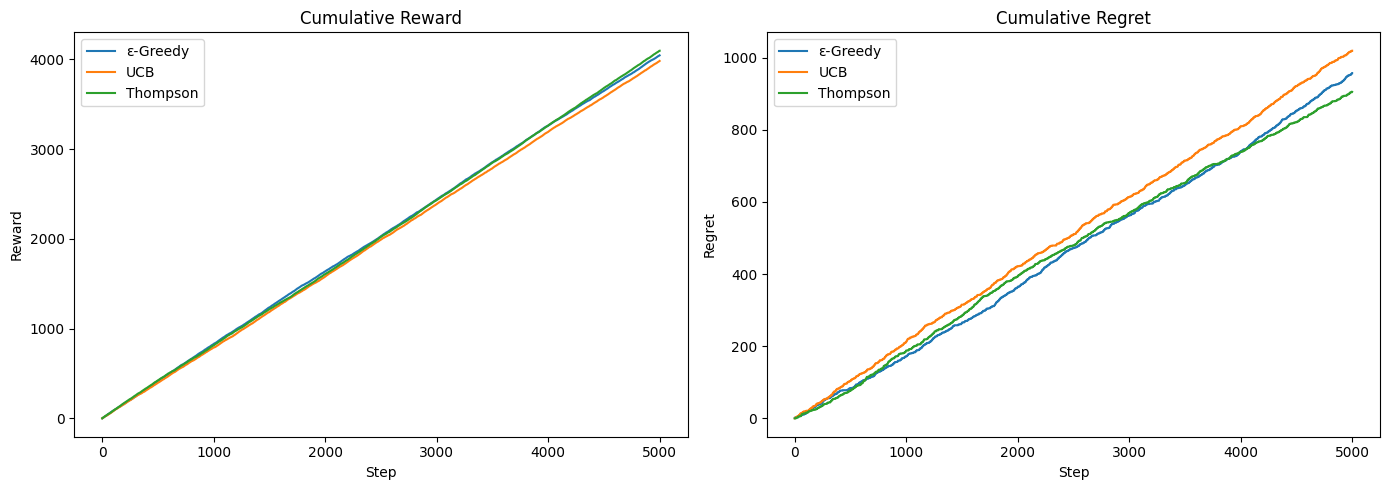

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, rewards, regrets in [
    ("ε-Greedy", eg_rewards, eg_regrets),
    ("UCB", ucb_rewards, ucb_regrets),
    ("Thompson", ts_rewards, ts_regrets),
]:
    axes[0].plot(rewards, label=label)
    axes[1].plot(regrets, label=label)

axes[0].set(title="Cumulative Reward", xlabel="Step", ylabel="Reward")
axes[0].legend()
axes[1].set(title="Cumulative Regret", xlabel="Step", ylabel="Regret")
axes[1].legend()
plt.tight_layout()
plt.show()

In [8]:
n = len(eg_rewards)
summary = pd.DataFrame({
    "Policy": ["ε-Greedy", "UCB", "Thompson Sampling"],
    "Total Reward": [eg_rewards[-1], ucb_rewards[-1], ts_rewards[-1]],
    "Total Regret": [eg_regrets[-1], ucb_regrets[-1], ts_regrets[-1]],
    "Hit Rate": [eg_rewards[-1]/n, ucb_rewards[-1]/n, ts_rewards[-1]/n],
})
summary

,Policy,Total Reward,Total Regret,Hit Rate
0,ε-Greedy,4043,957.0,0.8086
1,UCB,3981,1019.0,0.7962
2,Thompson Sampling,4095,905.0,0.8190


## Interactive Demo (Online Loop)

This demonstrates the MAB loop in real time using Thompson Sampling. A small subset of products is used. Each round: the system picks a product, you respond with `y` (liked) or `n` (didn't), and the arm's belief updates immediately. Type `q` to stop early.

In [9]:
demo_products = np.random.choice(products, size=20, replace=False)
demo = ThompsonSampling(demo_products)

for r in range(15):
    chosen = demo.select_arm()
    a, b = demo.arms[chosen]
    response = input(f"Round {r+1}: Recommend '{chosen}' (belief: α={a}, β={b}). Liked? (y/n/q): ")

    if response.strip().lower() == "q":
        break

    reward = 1 if response.strip().lower() == "y" else 0
    demo.update(chosen, reward)
    a_new, b_new = demo.arms[chosen]
    print(f"  → Updated: α={a_new}, β={b_new} (expected reward: {a_new/(a_new+b_new):.2f})\n")

  → Updated: α=2, β=1 (expected reward: 0.67)

  → Updated: α=2, β=1 (expected reward: 0.67)

  → Updated: α=2, β=1 (expected reward: 0.67)

  → Updated: α=1, β=2 (expected reward: 0.33)

  → Updated: α=1, β=2 (expected reward: 0.33)

  → Updated: α=1, β=2 (expected reward: 0.33)

  → Updated: α=1, β=2 (expected reward: 0.33)

  → Updated: α=1, β=2 (expected reward: 0.33)

  → Updated: α=2, β=2 (expected reward: 0.50)

  → Updated: α=2, β=1 (expected reward: 0.67)

  → Updated: α=3, β=1 (expected reward: 0.75)

  → Updated: α=2, β=1 (expected reward: 0.67)

  → Updated: α=2, β=1 (expected reward: 0.67)

  → Updated: α=3, β=2 (expected reward: 0.60)

  → Updated: α=1, β=2 (expected reward: 0.33)

